In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [3]:
df = pd.read_csv(r"C:\Users\user\Downloads\Telco-Customer-Churn.csv")
print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [4]:
print("Missing values:")
print(df.isnull().sum())
print("\nChurn distribution:")
print(df['Churn'].value_counts())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [5]:
# TotalCharges might have hidden issues
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].unique()[:10])

str
<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95']
Length: 10, dtype: str


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("Missing after conversion:", df['TotalCharges'].isnull().sum())

TotalCharges dtype: float64
Missing after conversion: 11


In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print("Missing after fix:", df['TotalCharges'].isnull().sum())

Missing after fix: 0


In [11]:
# Check categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)
print("Total:", len(cat_cols))

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Total: 17


In [12]:
# Drop customerID - not useful
df = df.drop(columns=['customerID'])

# Convert Churn to 0 and 1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn sample:", df['Churn'].value_counts())

Churn sample: Churn
0    5174
1    1869
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Done! Sample:")
print(df.head())
print("\nMissing values:", df.isnull().sum().sum())

Done! Sample:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1   

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 5634
Testing rows: 1409


In [15]:
# Build and train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 81.69 %


Top 5 churn risk factors:
PhoneService        1.021765
Contract            0.723166
PaperlessBilling    0.358453
OnlineSecurity      0.291946
TechSupport         0.256936
dtype: float64


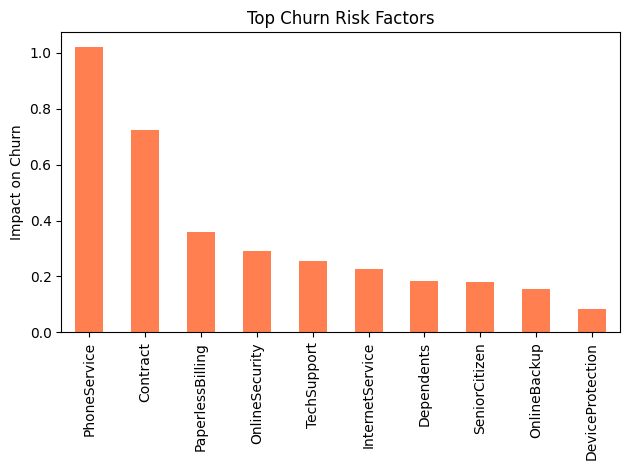

In [16]:
# Feature importance
importance = pd.Series(model.coef_[0], index=X.columns)
importance = importance.abs().sort_values(ascending=False)

print("Top 5 churn risk factors:")
print(importance.head())

# Plot
importance.head(10).plot(kind='bar', color='coral')
plt.title('Top Churn Risk Factors')
plt.ylabel('Impact on Churn')
plt.tight_layout()
plt.show()